In [1]:
import numpy as np
import pytest
import pyccl as ccl
from pyccl import CCLWarning

from pyccl.pk2d import Pk2D
from pyccl.correlations import correlation

In [2]:
#load covariance matrix and dv from cosmolike
cov_file = './cocoa/Cocoa/projects/roman_fourier/data/cov_roman_fourier'
mask_file = './cocoa/Cocoa/projects/roman_fourier/data/roman_Y3.mask'
mask = np.loadtxt(mask_file)[:,1].astype(bool)
cov_raw = np.loadtxt(cov_file)
ncov = int(np.max(cov_raw[:,0]))+1
cov = np.zeros((ncov, ncov))
for i in range(len(cov_raw)):
    ii = int(cov_raw[i, 0])
    jj = int(cov_raw[i, 1])
    element = cov_raw[i,8] + cov_raw[i,9]
    cov[ii,jj] = element
    cov[jj,ii] = element

### SETUP0

In [3]:
#----------------------------------------------------------------------------#
#----------------------------------------------------------------------------#
SETUP = 'setup0'
#----------------------------------------------------------------------------#
#----------------------------------------------------------------------------#

# ccl.gsl_params.LENSING_KERNEL_SPLINE_INTEGRATION = False
# setup cosmology
COSMO = ccl.Cosmology(
    Omega_c=0.26507647072945384,
    Omega_b=0.0495,
    Omega_k=0,
    h=0.6732,
    w0=-1,
    wa=0,
    A_s=2.1/1e9,
    n_s=0.96605,
    m_nu=0.06,
    Neff=3.046,
    mass_split='single',
    transfer_function='boltzmann_camb',
    matter_power_spectrum='camb',
    extra_parameters = {"camb": {"halofit_version": "takahashi",
                                 'AccuracyBoost': 1.0,
                                 'kmax':15,
                                 'dark_energy_model': 'ppf',
                                 'accurate_massive_neutrino_transfer': False,
                                 'k_per_logint': 15,
                                 }}
    )
h=0.6732

#-----------------------------------------------------------------#
#---------------based on discussion in section 0------------------#
#------------------we use this power spectrum---------------------#
#-----------------------------------------------------------------# 

filepath = f'./cocoa/Cocoa/projects/roman_fourier/chains/roman_{SETUP}_evaluate/'
z_pk_cocoa = np.loadtxt(filepath+'z_pk_1.txt')
k_pk_cocoa = np.loadtxt(filepath+'k_pk_1.txt')   #1/Mpc
lnPk_cocoa = np.loadtxt(filepath+'pknl_1.txt').reshape(len(k_pk_cocoa),len(z_pk_cocoa) ).T   #Mpc/h^3
lnPk_lin_cocoa = np.loadtxt(filepath+'pkln_1.txt').reshape(len(k_pk_cocoa),len(z_pk_cocoa) ).T   #Mpc/h^3
lnPk_cocoa = lnPk_cocoa[::-1,:] - 3*np.log(h)
lnPk_lin_cocoa = lnPk_lin_cocoa[::-1,:] - 3*np.log(h)
a_pk_cocoa = 1/(1+z_pk_cocoa)[::-1]
lnk_pk_cocoa = np.log(k_pk_cocoa)

pk2_cocoa = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=lnPk_cocoa, is_logp=True)
pk2_lin_cocoa = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=lnPk_lin_cocoa, is_logp=True)
pk2_ccl     = COSMO.nonlin_matter_power(k = np.exp(lnk_pk_cocoa), a = a_pk_cocoa)
pk2_lin_ccl = COSMO.linear_matter_power(k = np.exp(lnk_pk_cocoa), a = a_pk_cocoa)
pk2_ccl     = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=np.log(pk2_ccl), is_logp=True)
pk2_lin_ccl = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=np.log(pk2_lin_ccl), is_logp=True)

#---------------------------------------------------------------------------------------------#
#-------------------this Pk is further injected into power specetrum calculation--------------#
#---------------------------------------------------------------------------------------------#


#set up lens source sample
srcs_nzs = np.loadtxt('./cocoa/Cocoa/projects/roman_fourier/data/fiducial.nz')
lens_nzs = np.loadtxt('./cocoa/Cocoa/projects/roman_fourier/data/lsst_lens_4cosmolike.nz')

z_srcs = srcs_nzs[:,0]+0.005
srcs_nz = srcs_nzs[:,1:]
z_lens = lens_nzs[:,0]+0.005
lens_nz = lens_nzs[:,1:]

srcs = []
lens = []
nsrcs = 8
nlens = 10
gbias =  [1.09,1.15,1.21,1.27,1.33,1.40,1.46,1.53,1.60,1.67]
ggl_exclude = []

for i in range(nsrcs):
    srcs.append(ccl.WeakLensingTracer(COSMO, dndz=(z_srcs, srcs_nz[:,i]), has_shear=True, n_samples=400))
for i in range(nlens):
    lens.append(ccl.NumberCountsTracer(COSMO, dndz=(z_lens, lens_nz[:,i]), bias=(z_lens,np.ones_like(z_lens)*gbias[i]), has_rsd=False, n_samples=400))


#calculate the power spectrum
ncl= 20
lmin = 20
lmax = 4000
logdl = (np.log(lmax) - np.log(lmin))/ncl
ells = np.zeros(int(ncl))
for i in range(int(ncl)):
    ells[i] = np.exp(np.log(lmin) + (i + 0.5)*logdl)

corrs = []
for i in range(nsrcs):
    for j in range(i,nsrcs):
        corrs.append(ccl.angular_cl(COSMO, srcs[i], srcs[j], ells, p_of_k_a=pk2_cocoa, l_limber=-1) )
        
for i in range(nlens):
    for j in range(nsrcs):
        if [i,j] in ggl_exclude:
            continue
        corrs.append(ccl.angular_cl(COSMO, lens[i], srcs[j], ells, p_of_k_a=pk2_cocoa, l_limber=-1) )
        
for i in range(nlens):
    corrs.append(ccl.angular_cl(COSMO, lens[i], lens[i], ells, p_of_k_a=pk2_cocoa, l_limber=-1))
    
dv_ccl = np.concatenate((corrs))

dv_cosmolike = np.loadtxt(f'./cocoa/Cocoa/projects/roman_fourier/chains/roman_{SETUP}_evaluate/roman.modelvector_1')[:,1]

import importlib
import utils
importlib.reload(utils)

utils.compare(
    dv_ccl,
    dv_cosmolike,
    cov,
    mask,
    'ccl',
    'cosmolike',
    'fourier',
    10,
    8,
    1,
    500,
    20,
    [True, True, True],
    [True, True, True],
    [True, True, True],
    True,
    True,
    True,
    False,
)

ss chi2 is 0.006/0.052
gs chi2 is 0.007/0.050
gg chi2 is 0.001/0.051
3x2pt chi2 is 0.012/0.124


### SETUP1

In [3]:
#----------------------------------------------------------------------------#
#----------------------------------------------------------------------------#
SETUP = 'setup1'
#----------------------------------------------------------------------------#
#----------------------------------------------------------------------------#

# ccl.gsl_params.LENSING_KERNEL_SPLINE_INTEGRATION = False
# setup cosmology
COSMO = ccl.Cosmology(
    Omega_c=0.26507647072945384,
    Omega_b=0.0495,
    Omega_k=0,
    h=0.6732,
    w0=-1,
    wa=0,
    A_s=2.1/1e9,
    n_s=0.96605,
    m_nu=0.06,
    Neff=3.046,
    mass_split='single',
    transfer_function='boltzmann_camb',
    matter_power_spectrum='camb',
    extra_parameters = {"camb": {"halofit_version": "takahashi",
                                 'AccuracyBoost': 1.0,
                                 'kmax':15,
                                 'dark_energy_model': 'ppf',
                                 'accurate_massive_neutrino_transfer': False,
                                 'k_per_logint': 15,
                                 }}
    )
h=0.6732

#-----------------------------------------------------------------#
#---------------based on discussion in section 0------------------#
#------------------we use this power spectrum---------------------#
#-----------------------------------------------------------------# 

filepath = f'./cocoa/Cocoa/projects/roman_fourier/chains/roman_{SETUP}_evaluate/'
z_pk_cocoa = np.loadtxt(filepath+'z_pk_1.txt')
k_pk_cocoa = np.loadtxt(filepath+'k_pk_1.txt')   #1/Mpc
lnPk_cocoa = np.loadtxt(filepath+'pknl_1.txt').reshape(len(k_pk_cocoa),len(z_pk_cocoa) ).T   #Mpc/h^3
lnPk_lin_cocoa = np.loadtxt(filepath+'pkln_1.txt').reshape(len(k_pk_cocoa),len(z_pk_cocoa) ).T   #Mpc/h^3
lnPk_cocoa = lnPk_cocoa[::-1,:] - 3*np.log(h)
lnPk_lin_cocoa = lnPk_lin_cocoa[::-1,:] - 3*np.log(h)
a_pk_cocoa = 1/(1+z_pk_cocoa)[::-1]
lnk_pk_cocoa = np.log(k_pk_cocoa)

pk2_cocoa = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=lnPk_cocoa, is_logp=True)
pk2_lin_cocoa = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=lnPk_lin_cocoa, is_logp=True)
pk2_ccl     = COSMO.nonlin_matter_power(k = np.exp(lnk_pk_cocoa), a = a_pk_cocoa)
pk2_lin_ccl = COSMO.linear_matter_power(k = np.exp(lnk_pk_cocoa), a = a_pk_cocoa)
pk2_ccl     = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=np.log(pk2_ccl), is_logp=True)
pk2_lin_ccl = Pk2D(a_arr=a_pk_cocoa, lk_arr=lnk_pk_cocoa, pk_arr=np.log(pk2_lin_ccl), is_logp=True)

#---------------------------------------------------------------------------------------------#
#-------------------this Pk is further injected into power specetrum calculation--------------#
#---------------------------------------------------------------------------------------------#


#set up lens source sample
srcs_nzs = np.loadtxt('./cocoa/Cocoa/projects/roman_fourier/data/fiducial.nz')
lens_nzs = np.loadtxt('./cocoa/Cocoa/projects/roman_fourier/data/lsst_lens_4cosmolike.nz')

z_srcs = srcs_nzs[:,0]+0.005
srcs_nz = srcs_nzs[:,1:]
z_lens = lens_nzs[:,0]+0.005
lens_nz = lens_nzs[:,1:]

srcs = []
lens = []
nsrcs = 8
nlens = 10
gbias =  [1.09,1.15,1.21,1.27,1.33,1.40,1.46,1.53,1.60,1.67]
ggl_exclude = []

for i in range(nsrcs):
    srcs.append(ccl.WeakLensingTracer(COSMO, dndz=(z_srcs, srcs_nz[:,i]), ia_bias=(z_srcs, np.ones_like(z_srcs)*0.5), has_shear=True, use_A_ia=True, n_samples=150))
for i in range(nlens):
    lens.append(ccl.NumberCountsTracer(COSMO, dndz=(z_lens, lens_nz[:,i]), bias=(z_lens,np.ones_like(z_lens)*gbias[i]), has_rsd=True, n_samples=400))


#calculate the power spectrum
ncl= 20
lmin = 20
lmax = 4000
logdl = (np.log(lmax) - np.log(lmin))/ncl
ells = np.zeros(int(ncl))
for i in range(int(ncl)):
    ells[i] = np.exp(np.log(lmin) + (i + 0.5)*logdl)

corrs = []
for i in range(nsrcs):
    for j in range(i,nsrcs):
        corrs.append(ccl.angular_cl(COSMO, srcs[i], srcs[j], ells, p_of_k_a=pk2_cocoa, l_limber=-1) )
        
for i in range(nlens):
    for j in range(nsrcs):
        if [i,j] in ggl_exclude:
            continue
        corrs.append(ccl.angular_cl(COSMO, lens[i], srcs[j], ells, p_of_k_a=pk2_cocoa, l_limber=-1) )
        
for i in range(nlens):
    corrs.append(ccl.angular_cl(COSMO, lens[i], lens[i], ells, p_of_k_a=pk2_cocoa, l_limber=150,
                                    limber_max_error=0.001,
                                    non_limber_integration_method='FKEM',
                                    fkem_chi_min = None,
                                    fkem_Nchi = 5000,
                                    p_of_k_a_lin = pk2_lin_cocoa,))
    
dv_ccl = np.concatenate((corrs))

dv_cosmolike = np.loadtxt(f'./cocoa/Cocoa/projects/roman_fourier/chains/roman_{SETUP}_evaluate/roman.modelvector_1')[:,1]

import importlib
import utils
importlib.reload(utils)

utils.compare(
    dv_ccl,
    dv_cosmolike,
    cov,
    mask,
    'ccl',
    'cosmolike',
    'fourier',
    10,
    8,
    20,
    4000,
    20,
    [True, True, True],
    [True, True, True],
    [True, True, True],
    True,
    True,
    True,
    False,
)

/project/chihway/junzhou/Code-comparison/ccl/pyccl/errors.py:22: CCLWarning: chi_min must be greater than zero.Setting to default 1e-6 Mpc.
  warnings_builtin.warn(*args, **kwargs)


ss chi2 is 0.003/0.026
gs chi2 is 0.005/0.062
gg chi2 is 0.031/0.050
3x2pt chi2 is 0.075/0.198


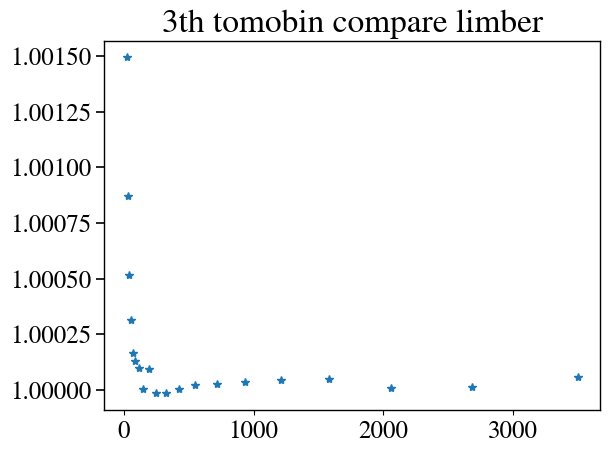

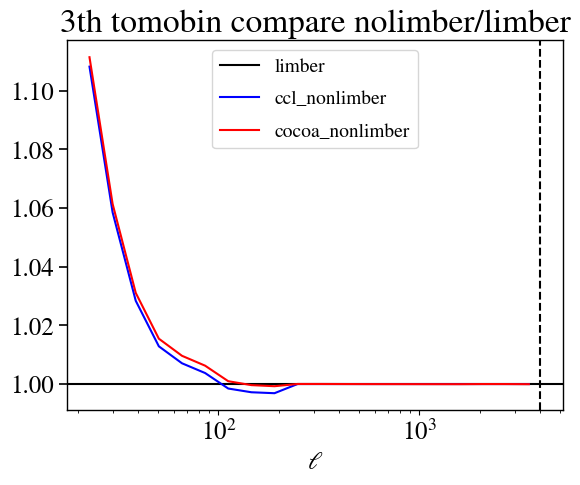

In [5]:
import matplotlib.pyplot as plt
nlens = 10
nsrcs = 8
nbins = 20
ggl_exclude = []
ELLMAX = 4000
wtheta_start = int( (nsrcs*(nsrcs+1)/2 + nsrcs*nlens - len(ggl_exclude))*nbins )
i = 3

ccl_wtheta_nolimber = ccl.angular_cl(COSMO, lens[i], lens[i], ells, p_of_k_a=pk2_cocoa, l_limber=4000,
                                    limber_max_error=0.001,
                                    non_limber_integration_method='FKEM',
                                    fkem_chi_min = None,
                                    fkem_Nchi = 5000,
                                    p_of_k_a_lin = pk2_lin_cocoa,)
ccl_wtheta_limber = ccl.angular_cl(COSMO, lens[i], lens[i], ells, p_of_k_a=pk2_cocoa, l_limber=-1)
cocoa_wtheta_nolimber = np.loadtxt(f'./cocoa/Cocoa/projects/roman_fourier/chains/roman_nonlimber_evaluate/roman.modelvector_1')[:,1][wtheta_start + i*nbins:wtheta_start + i*nbins + nbins]
cocoa_wtheta_limber = np.loadtxt(f'./cocoa/Cocoa/projects/roman_fourier/chains/roman_limber_evaluate/roman.modelvector_1')[:,1][wtheta_start + i*nbins:wtheta_start + i*nbins + nbins]


plt.plot(ells, ccl_wtheta_limber/cocoa_wtheta_limber, '*')
plt.title(f'{i}th tomobin compare limber')
plt.show()

plt.axhline(y = 1, xmin = 0, xmax = 1, c = 'k', label = 'limber')
plt.plot(ells, ccl_wtheta_nolimber/ccl_wtheta_limber, 'b', label = 'ccl_nonlimber')
plt.plot(ells, cocoa_wtheta_nolimber/ccl_wtheta_limber, 'r', label = 'cocoa_nonlimber')
plt.axvline(x = ELLMAX, ymin = 0, ymax = 1, c = 'k', linestyle='--')
plt.xscale('log')
plt.xlabel(r'$\ell$')
plt.title(f'{i}th tomobin compare nolimber/limber')
plt.legend()
plt.show()